In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from salishsea_tools import viz_tools
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean.cm as cm
import matplotlib.dates as mdates

# Data Import

In [2]:
site_information = pd.read_csv('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/stair_collab/julie_temperature/Coordinates_of_2025_fieldsites.csv')
site_information

,WKT,Site,Latitude,Longitude
0,POINT (-123.311029 48.868089),Arbutus Point,48.868089,-123.311029
1,POINT (-123.035292 49.004776),Boundary Bay Boat Ramp,49.004776,-123.035292
2,POINT (-123.244135 49.470572),Brunswick Beach,49.470572,-123.244135
3,POINT (-123.72661 49.440808),Davis Bay,49.440808,-123.726610
4,POINT (-123.947317 49.509379),Halfmoon Bay,49.509379,-123.947317
5,POINT (-125.222963 50.116111),Hyacinthe Bay,50.116111,-125.222963
6,POINT (-123.265178 49.330167),Lighhouse Park,49.330167,-123.265178
7,POINT (-123.222317 49.339313),McKechnie Park,49.339313,-123.222317
8,POINT (-123.234589 49.559837),Porteau Cove,49.559837,-123.234589
9,POINT (-123.183509 49.27329),Royal Vancouver Yacht Club,49.273290,-123.183509


In [3]:
site_coords = site_information.set_index('Site')[['Latitude', 'Longitude']].drop_duplicates().groupby('Site').mean().to_dict('index')

In [4]:
bathy = xr.open_dataset('/home/sallen/MEOPAR/grid/bathymetry_202108.nc')
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')
tmask = 1 - mesh.tmask[0]

# Functions

In [5]:
def grid_from_latlon(lat_coord, lon_coord):
    lat_diff = np.abs(bathy.nav_lat - lat_coord)
    lon_diff  = np.abs(bathy.nav_lon - lon_coord)
    sum_of_diff = lat_diff + lon_diff
    intersect_idx = np.unravel_index(np.nanargmin(np.ma.masked_array(sum_of_diff, mask=tmask[5]).filled(np.nan)), sum_of_diff.shape)

    fig, ax = plt.subplots(1,2)
    cb = ax[0].pcolormesh(sum_of_diff)
    ax[0].set_ylabel('GridY')
    ax[0].set_xlabel('GridX')
    viz_tools.set_aspect(ax[0]);
    
    cb2 = ax[1].pcolormesh(np.ma.masked_array(sum_of_diff, mask=tmask[5]))
    ax[1].set_ylabel('GridY')
    ax[1].set_xlabel('GridX')
    viz_tools.set_aspect(ax[1]);
    ax[1].plot(intersect_idx[1], intersect_idx[0], 'r*')

    fig.colorbar(cb, ax=ax[:], label='Lat Diff + Lon Diff')

    print('(y, x): {}'.format(intersect_idx))
    print('Bathy: {} m'.format(bathy['Bathymetry'].isel(y=intersect_idx[0], x=intersect_idx[1]).values))

In [6]:
def plot_water_levels(site_name):
    temp_logged_site = temp_logged[temp_logged['Site'] == site_name]
    temp_logged_site['time'] = pd.to_datetime(temp_logged_site['Date_UTC'], format='%Y-%m-%d %H:%M')

    fig, ax = plt.subplots(1,1)
    ax.plot(temp_logged_site['time'], temp_logged_site['Water_level_m'], '-')
    print(temp_logged_site['time'].min())
    print(temp_logged_site['time'].max())
    print(len(temp_logged_site['time']))

    return temp_logged_site

In [7]:
def plot_temp_ts(temp_logged_site):

    fig, ax = plt.subplots(1,1)
    ax.plot(temp_logged_site['time'], temp_logged_site['Mean_temp_C'], '-')
    print(temp_logged_site['Mean_temp_C'].min())
    print(temp_logged_site['Mean_temp_C'].max())

In [8]:
def bias(obs, mod):
    return np.mean(mod - obs)

In [9]:
def rmse(obs, mod):
    return (np.sqrt(((mod - obs)**2).mean()))

In [10]:
def check_depth_stats(site_name, dep_sel, model_loc_filt_time, temp_logged_loc):
    model_loc_filt_time_dep_sel = model_loc_filt_time.isel(depth=dep_sel)
    
    diff_loc_sel = model_loc_filt_time_dep_sel.votemper[:,0,0].values - temp_logged_loc['Mean_temp_C']
    bias_loc_sel = round(bias(temp_logged_loc['Mean_temp_C'], model_loc_filt_time_dep_sel.votemper[:,0,0].values),2)
    rmse_loc_sel = round(rmse(temp_logged_loc['Mean_temp_C'], model_loc_filt_time_dep_sel.votemper[:,0,0].values),2)

    fig, ax = plt.subplots(1,1, figsize=(8, 2))
    ax.plot(temp_logged_loc['time'], diff_loc_sel,'.', markersize=2, color='k', label='residuals')
    ax.hlines(0, temp_logged_loc['time'].min(), temp_logged_loc['time'].max(), color='r', zorder=0)
    ax.set_ylabel(r'Temperature [$^\circ$C]')
    ax.set_title('{}\nResiduals [mod - obs] for depth = {}\nBias: {}\nRMSE: {}'.format(site_name, round(float(model_loc.depth[dep_sel]), 1), bias_loc_sel, rmse_loc_sel))
    ax.legend()
    # ax.set_xticks(rotation=90)
    ax.tick_params(axis='x', labelrotation=45)

    return(bias_loc_sel, rmse_loc_sel)



# Model-Logger Evaluations

Hyacinthe Bay
(y, x): (761, 137)
Bathy: 15.25 m


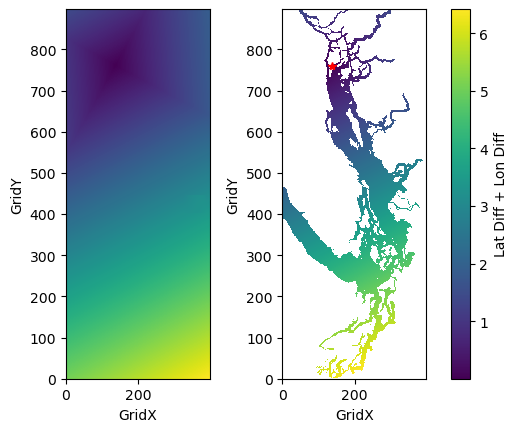

In [12]:
site_name = 'Hyacinthe Bay'
save_tag = 'hyacinthe'
lat, lon = site_coords[site_name].values()
print(site_name)
grid_from_latlon(lat, lon)

# Visualizations and Timeseries

In [13]:
dep_sel = 1

## Functions

In [14]:
color_sal = '#25738a'
color_temp = '#cc5e0f'

In [15]:
def plot_timeseries(daily_xr, site_name):
    fig, ax = plt.subplots(2,1,  figsize = (12,3), sharex=True)
    fig.suptitle(site_name)

    ax[0].plot(daily_xr['time'], daily_xr.vosaline, color=color_sal, alpha=1)
    ax[0].set_ylabel('Salinity [g/kg]')
    ax[0].grid(axis='y', color='#737373', linestyle=(0, (1, 10)))
    ax[0].grid(axis='x', color='#737373', linestyle=(0, (1, 10)))

    ax[1].plot(daily_xr['time'], daily_xr.votemper, color=color_temp, alpha=1)
    ax[1].set_ylabel('Temperature [degC]')
    ax[1].grid(axis='y', color='#737373', linestyle=(0, (1, 10)))
    ax[1].grid(axis='x', color='#737373', linestyle=(0, (1, 10)))
    ax[1].set_xlim([daily_xr['time'].min(), daily_xr['time'].max()])

In [16]:
def make_df(daily_xr):
    vars_loc_df = daily_xr.to_dataframe().drop(columns=['depth', 'gridY', 'gridX']).reset_index()
    vars_loc_df['month-day'] = vars_loc_df['time'].dt.strftime('%m-%d')
    vars_loc_df['year'] = vars_loc_df['time'].dt.strftime('%Y')

    vars_loc_df_mean = vars_loc_df.groupby('month-day').mean(numeric_only=True).reset_index()

    return vars_loc_df, vars_loc_df_mean

In [17]:
def plot_stacked_timeseries(vars_loc_df, vars_loc_df_mean, site_name):
    fig, ax = plt.subplots(2,1,  figsize = (12,3), sharex=True)
    fig.suptitle(site_name)

    vars_loc_df['month-day'] = pd.to_datetime('2001-' + vars_loc_df['month-day'], errors='coerce')
    vars_loc_df_mean['month-day'] = pd.to_datetime('2001-' + vars_loc_df_mean['month-day'], errors='coerce')

    for year in vars_loc_df['year'].unique():

        ax[0].plot(vars_loc_df[vars_loc_df['year'] == year]['month-day'], vars_loc_df[vars_loc_df['year'] == year]['vosaline'], color=color_sal, alpha=0.3)
        ax[0].set_ylabel('Salinity [g/kg]')
        ax[0].grid(axis='y', color='#737373', linestyle=(0, (1, 10)))
        ax[0].grid(axis='x', color='#737373', linestyle=(0, (1, 10)))

        ax[1].plot(vars_loc_df[vars_loc_df['year'] == year]['month-day'], vars_loc_df[vars_loc_df['year'] == year]['votemper'], color=color_temp, alpha=0.3)
        ax[1].set_ylabel('Temperature [degC]')
        ax[1].grid(axis='y', color='#737373', linestyle=(0, (1, 10)))
        ax[1].grid(axis='x', color='#737373', linestyle=(0, (1, 10)))
        
        ax[1].set_xlim([vars_loc_df['month-day'].min(), vars_loc_df['month-day'].max()])
        ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        # ax[1].set_xticks(['01-01', '02-01', '03-01', '04-01', '05-01', '06-01', '07-01', '08-01', '09-01', '10-01', '11-01', '12-01', '12-31'])

    ax[0].plot(vars_loc_df_mean['month-day'], vars_loc_df_mean['vosaline'], color='k', alpha=1)
    ax[1].plot(vars_loc_df_mean['month-day'], vars_loc_df_mean['votemper'], color='k', alpha=1)

In [18]:
def plot_hist(vars_loc_df, site_name):

    bin_num = 15

    fig, ax = plt.subplots(1,2, figsize = (12, 3), sharex=True)
    # fig.tight_layout(pad=1.6)
    fig.suptitle(site_name)

    ax[0].set_ylabel(r'Salinity [g/kg]')
    ax[0].hist(vars_loc_df['vosaline'], bins=bin_num, color=color_sal, edgecolor='black', orientation='horizontal')

    ax[1].set_ylabel(r'Temperature $^{\circ}$C')
    ax[1].set_xlabel(r'# Days')
    ax[1].hist(vars_loc_df['votemper'], bins=bin_num, color=color_temp, edgecolor='black', orientation='horizontal')

In [19]:
def print_stats(vars_loc_df):
    print('---- Salinity ---------------- \n\
    Mean:               {:.2f} (g/kg) \n\
    Median:             {:.2f} (g/kg) \n\
    Standard Deviation: {:.2f} (g/kg)'.format(vars_loc_df['vosaline'].mean(), np.median(vars_loc_df['vosaline']), vars_loc_df['vosaline'].std()))

    print('---- Temperature ---------------- \n\
    Mean:               {:.2f} (degC) \n\
    Median:             {:.2f} (degC) \n\
    Standard Deviation: {:.2f} (degC)'.format(vars_loc_df['votemper'].mean(), np.median(vars_loc_df['votemper']), vars_loc_df['votemper'].std()))

## Analysis and Figures

In [20]:
model_daily = xr.open_dataset('/ocean/cdonaldson/stair_extractions/julie/SalishSeaCast_daily_phys_00_02_{}_20200101_20251231.nc'.format(save_tag)).isel(depth=dep_sel, gridX=0, gridY=0)
model_daily

<xarray.Dataset>
Dimensions:   (time: 2192)
Coordinates:
  * time      (time) datetime64[ns] 2020-01-01T12:00:00 ... 2025-12-31T12:00:00
    depth     float32 1.5
    gridY     int64 761
    gridX     int64 137
Data variables:
    votemper  (time) float32 ...
    vosaline  (time) float32 ...
Attributes:
    name:         SalishSeaCast_daily_phys_00_02_hyacinthe_20200101_20251231
    description:  Day-averaged physics extracted from SalishSeaCast v202111 N...
    history:      2026-04-03 12:35 -07:00: Generated by `reshapr extract /oce...
    Conventions:  CF-1.6

In [21]:
model_daily_alldep = xr.open_dataset('/ocean/cdonaldson/stair_extractions/julie/SalishSeaCast_daily_phys_00_02_{}_20200101_20251231.nc'.format(save_tag)).isel(gridX=0, gridY=0)

---- Salinity ---------------- 
    Mean:               27.07 (g/kg) 
    Median:             27.54 (g/kg) 
    Standard Deviation: 1.91 (g/kg)
---- Temperature ---------------- 
    Mean:               11.29 (degC) 
    Median:             10.26 (degC) 
    Standard Deviation: 4.30 (degC)


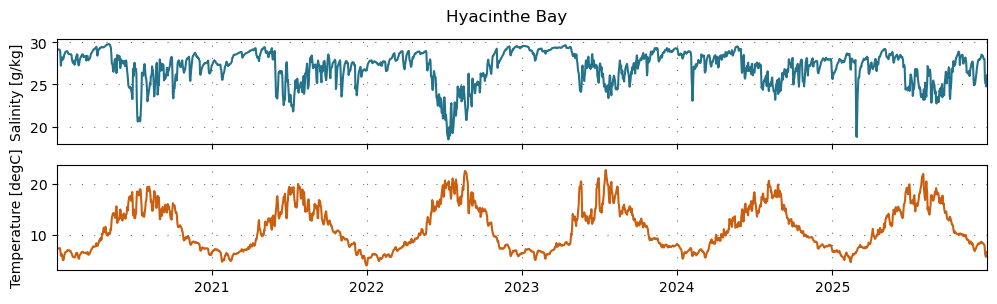

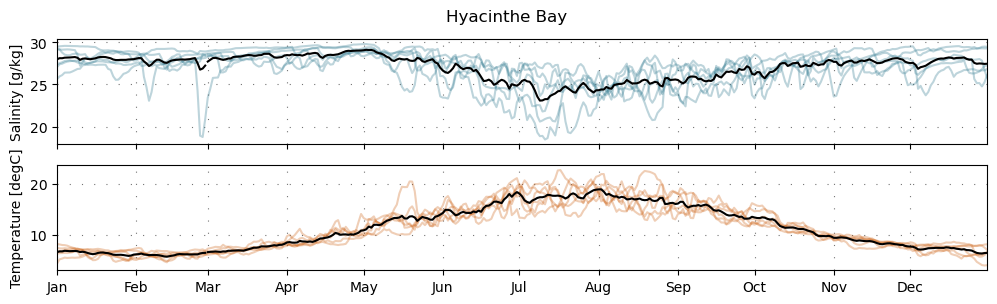

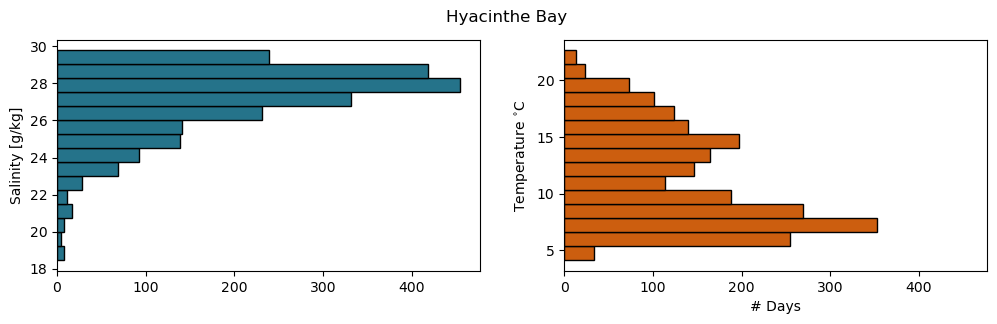

In [22]:
vars_loc_df, vars_loc_df_mean = make_df(model_daily)
print_stats(vars_loc_df)
plot_timeseries(model_daily, site_name)
plot_stacked_timeseries(vars_loc_df, vars_loc_df_mean, site_name)
plot_hist(vars_loc_df, site_name)

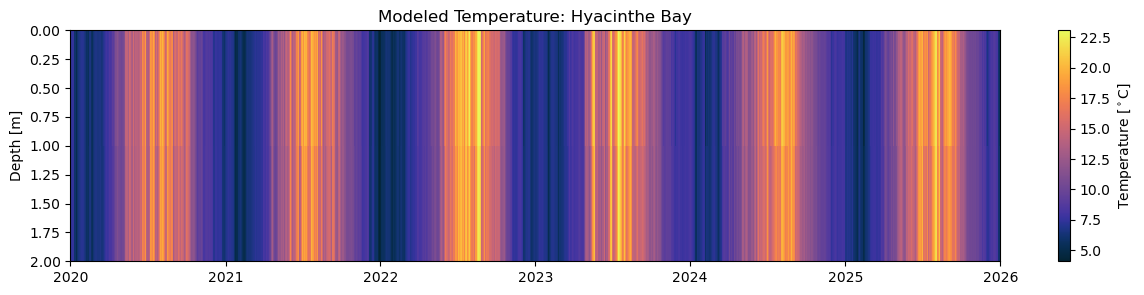

In [23]:
cmap = cm.thermal
fig, ax = plt.subplots(1,1, figsize=(15, 3))
colors = ax.pcolormesh(model_daily_alldep.time, model_daily_alldep.depth, model_daily_alldep.votemper[:,:].T, cmap=cmap)
ax.set_ylim([2,0])
ax.set_title('Modeled Temperature: {}'.format(site_name))
ax.set_ylabel('Depth [m]')
cb = fig.colorbar(colors, ax=ax, label=r'Temperature [$^\circ$C]', orientation='vertical')

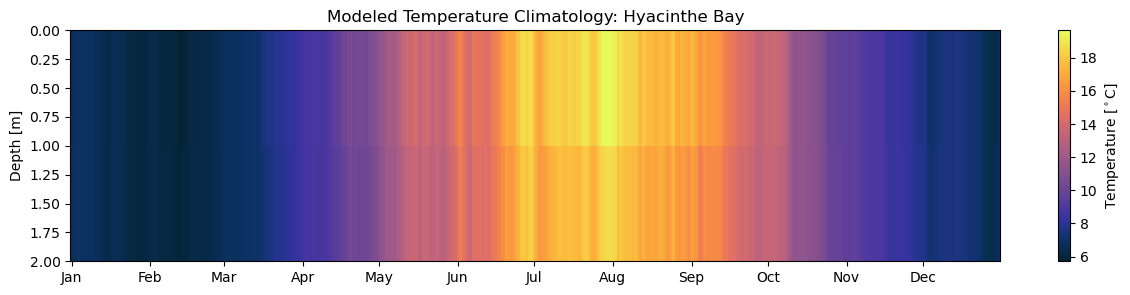

In [24]:
model_daily_alldep.coords['dayofyear'] = model_daily_alldep['time'].dt.dayofyear
daily_climatology = model_daily_alldep.groupby('dayofyear').mean('time')
days = pd.date_range('2000-01-01', '2000-12-31')
daily_climatology = daily_climatology.assign_coords(time=('dayofyear', days))

cmap = cm.thermal
fig, ax = plt.subplots(1,1, figsize=(15, 3))
colors = ax.pcolormesh(daily_climatology.time, daily_climatology.depth, daily_climatology.votemper[:,:].T, cmap=cmap)
ax.set_ylim([2,0])
ax.set_title('Modeled Temperature Climatology: {}'.format(site_name))
ax.set_ylabel('Depth [m]')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
cb = fig.colorbar(colors, ax=ax, label=r'Temperature [$^\circ$C]', orientation='vertical')

In [25]:
yrly_save = model_daily_alldep.isel(depth=1).to_dataframe().reset_index()[['time', 'votemper', 'vosaline']]
yrly_len = len(yrly_save)
yrly_save['Lat'] = [lat] * yrly_len
yrly_save['Lon'] = [lon] * yrly_len
yrly_save['Site'] = [site_name] * yrly_len
yrly_save.to_csv('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/stair_collab/julie_temperature/julie_model_data/temp_and_sal_model_daily_{}.csv'.format(site_name))

In [26]:
clim_save = daily_climatology.isel(depth=1).to_dataframe().reset_index()[['dayofyear', 'votemper', 'vosaline']]
clim_len = len(clim_save)
clim_save['Lat'] = [lat] * clim_len
clim_save['Lon'] = [lon] * clim_len
clim_save['Site'] = [site_name] * clim_len
clim_save.to_csv('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/stair_collab/julie_temperature/julie_model_data/temp_and_sal_model_clim_{}.csv'.format(site_name))